In [ ]:
from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

In [5]:
# ==========================================
# 1. Neural Network Architecture
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.loss_function = nn.MSELoss(reduction='mean')

        # Build neural network dynamically based on layers list
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

        # Xavier/Glorot initialization for better convergence
        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, x, t):
        # Input is concatenated spatial (x) and temporal (t) coordinates
        a = torch.cat([x, t], dim=1)
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        # No activation on the final output layer
        a = self.linears[-1](a)
        return a


In [6]:
# ==========================================
# 2. Physics-Informed Loss Components
# ==========================================
def compute_physics_loss(model, x_f, t_f, nu):
    # Require gradients for spatial and temporal inputs
    x_f.requires_grad_(True)
    t_f.requires_grad_(True)

    # Predict u
    u = model(x_f, t_f)

    # Compute gradients (autograd)
    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    # Burger's PDE residual: f = u_t + u * u_x - nu * u_xx = 0
    f = u_t + u * u_x - nu * u_xx

    # The physics loss is the Mean Squared Error of the residual (it should be 0)
    loss_f = nn.MSELoss()(f, torch.zeros_like(f))
    return loss_f

In [11]:
# ==========================================
# 3. Analytical Solution (Cole-Hopf)
# ==========================================
def analytical_burgers(x, t, nu):
    """
    Computes the exact analytical solution for 1D Burgers' equation
    using the Cole-Hopf transformation.
    IC: u(x,0) = -sin(pi*x)
    BC: u(-1,t) = u(1,t) = 0
    """
    if t == 0:
        return -np.sin(np.pi * x)

    # Create a highly dense grid for stable numerical integration
    eta = np.linspace(-5, 5, 100000)

    # Cole-Hopf exponent.
    # Note the PLUS sign: \int -sin(pi*x) -> + (1 - cos(pi*eta)) / (2*pi*nu)
    exponent = -((x - eta)**2) / (4 * nu * t) + (1.0 - np.cos(np.pi * eta)) / (2 * np.pi * nu)

    # Log-Sum-Exp trick: shift exponent by its maximum to prevent numerical overflow/underflow
    max_exp = np.max(exponent)
    exp_shifted = np.exp(exponent - max_exp)

    # Integrate using the Trapezoidal rule
    num = np.trapz(((x - eta) / t) * exp_shifted, eta)
    den = np.trapz(exp_shifted, eta)

    return num / den

In [8]:
# ==========================================
# 4. Training Data & Setup
# ==========================================
# Problem parameters
nu = 0.01 / np.pi # Kinematic viscosity
N_u = 100         # Number of initial/boundary condition points
N_f = 10000       # Number of collocation points for PDE

# Domain bounds
x_lower, x_upper = -1.0, 1.0
t_lower, t_upper = 0.0, 1.0

# Generate Initial Condition (t=0)
x_ic = np.random.uniform(x_lower, x_upper, (N_u, 1))
t_ic = np.zeros((N_u, 1))
u_ic = -np.sin(np.pi * x_ic)

# Generate Boundary Conditions (x=-1 and x=1)
x_bc_left = np.full((N_u, 1), x_lower)
x_bc_right = np.full((N_u, 1), x_upper)
t_bc = np.random.uniform(t_lower, t_upper, (N_u, 1))
u_bc = np.zeros((N_u, 1))

# Combine Boundary and Initial Conditions
x_data = np.vstack([x_ic, x_bc_left, x_bc_right])
t_data = np.vstack([t_ic, t_bc, t_bc])
u_data = np.vstack([u_ic, u_bc, u_bc])

# Generate Collocation Points (Inside the domain)
x_f = np.random.uniform(x_lower, x_upper, (N_f, 1))
t_f = np.random.uniform(t_lower, t_upper, (N_f, 1))

# Convert everything to PyTorch tensors
x_data_pt = torch.tensor(x_data, dtype=torch.float32)
t_data_pt = torch.tensor(t_data, dtype=torch.float32)
u_data_pt = torch.tensor(u_data, dtype=torch.float32)

x_f_pt = torch.tensor(x_f, dtype=torch.float32)
t_f_pt = torch.tensor(t_f, dtype=torch.float32)


In [9]:
# ==========================================
# 5. Training Loop
# ==========================================
# NN Layers: 2 inputs (x,t), 8 hidden layers with 20 neurons, 1 output (u)
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
model = PINN(layers)

# Optimizer (Adam is usually standard to start with in modern PINNs)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000

print("Starting Training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Data Loss (Initial & Boundary Conditions)
    u_pred = model(x_data_pt, t_data_pt)
    loss_data = model.loss_function(u_pred, u_data_pt)

    # 2. Physics Loss (PDE Collocation points)
    loss_physics = compute_physics_loss(model, x_f_pt, t_f_pt, nu)

    # Total Loss
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, Data Loss: {loss_data.item():.6f}, Physics Loss: {loss_physics.item():.6f}')

print("Training Complete!")



Starting Training...
Epoch: 00000, Total Loss: 0.175661, Data Loss: 0.167224, Physics Loss: 0.008437
Epoch: 01000, Total Loss: 0.027899, Data Loss: 0.019695, Physics Loss: 0.008204
Epoch: 02000, Total Loss: 0.017537, Data Loss: 0.003983, Physics Loss: 0.013555
Epoch: 03000, Total Loss: 0.003278, Data Loss: 0.001550, Physics Loss: 0.001727
Epoch: 04000, Total Loss: 0.002073, Data Loss: 0.000770, Physics Loss: 0.001302
Training Complete!


/tmp/ipykernel_737/246424255.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(((x - eta) / t) * exp_shifted, eta)
/tmp/ipykernel_737/246424255.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(exp_shifted, eta)


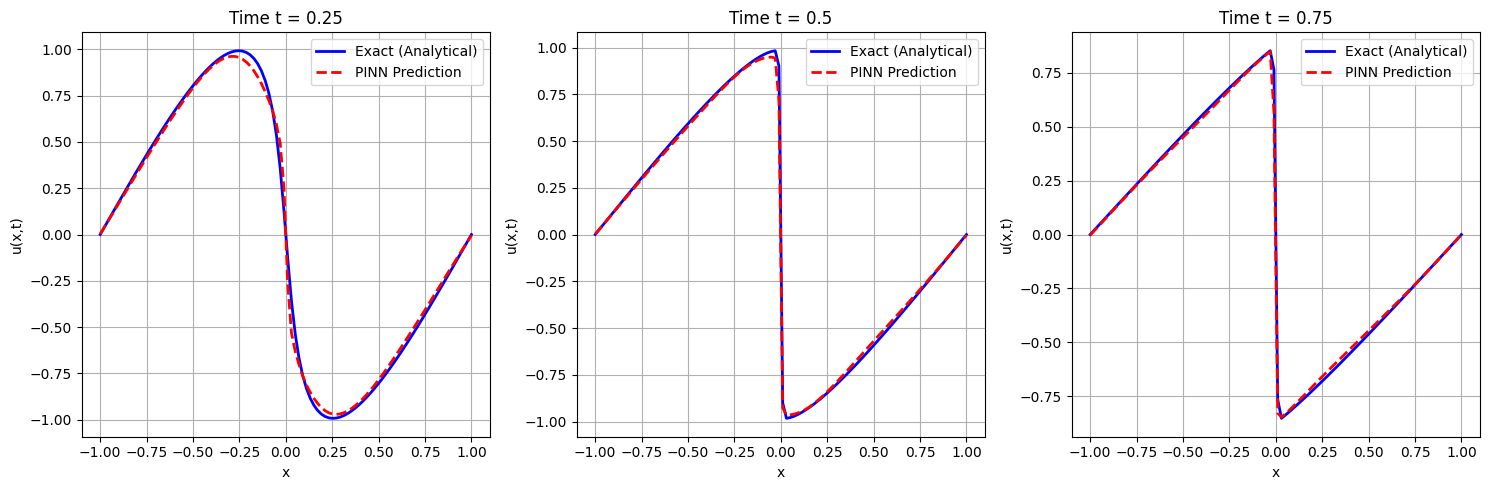

In [15]:
# ==========================================
# 6. Evaluation & Validation (PINN vs Analytical)
# ==========================================
# Create a grid for prediction
x_test = np.linspace(-1, 1, 100)
t_test = np.array([0.25, 0.50, 0.75])

plt.figure(figsize=(15, 5))

for i, t_val in enumerate(t_test):
    # Predict with PINN
    x_test_pt = torch.tensor(x_test[:, None], dtype=torch.float32)
    t_test_pt = torch.tensor(np.full((100, 1), t_val), dtype=torch.float32)

    with torch.no_grad():
        u_pred = model(x_test_pt, t_test_pt).numpy()

    # Calculate exact analytical solution
    u_exact = np.array([analytical_burgers(xi, t_val, nu) for xi in x_test])

    # Plotting
    plt.subplot(1, 3, i+1)
    plt.plot(x_test, u_exact, 'b-', label='Exact (Analytical)', linewidth=2)
    plt.plot(x_test, u_pred, 'r--', label='PINN Prediction', linewidth=2)
    plt.title(f'Time t = {t_val}')
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.savefig("burgers_pinn_results.png", dpi=300, bbox_inches='tight')
plt.show()

#

In [17]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks/.git/
